# Wyniki

Trzy przebiegi na tym samym podziale rodzinowym, plus baseline. Wszystkie dekoduja
przez PROBKOWANIE z ziarnem 0 i roznia sie WYLACZNIE kara za sklad. **Wszystkie komponenty straty mają
wagę 1,0**, więc żadna waga nie jest dobrana pod wynik.

```
E1        nasza kara TV za sklad
E2        kara progowa promotora
CE        wszystkie trzy kary wylaczone, sama cross-entropia (ablacja)
baseline  losowa sekwencja JEDNOSTAJNA (pary po 1/3, zasady po 1/4), zero wiedzy
```

## Co rozstrzyga

Zwykła identyczność ma wadę, którą trzeba znać: **jest maksymalizowana przez stałe wskazywanie klasy
najczęstszej**. Sekwencja z samych par G:C dostaje 48,4% identyczności par, czyli dokładnie tyle, ile
wynosi udział par G:C w referencji, i więcej niż uczciwy baseline.

Dlatego rozstrzygają **trafności zbalansowane**: czułość liczona osobno dla każdej klasy i uśredniona
bez wagi. Predyktor stały spada tam do 1/3 (pary) i 1/4 (zasady), niezależnie od tego, którą klasę
wybierze.

```
ident_nt     ulamek pozycji z ta sama zasada co referencja
ident_par    ulamek par z trafionym TYPEM; A-U i U-A to ten sam typ
zbal_par     srednia czulosc po typach par, BEZ wagi        <- rozstrzyga
specyficznosc  z tych, ktore NIE sa klasy c, ilu model nie wrzucil do c
zbal_zas     srednia czulosc po zasadach w petlach, BEZ wagi <- rozstrzyga
dE/nt        o ile stabilizujemy cel lepiej niz referencja; ujemne = lepiej
kara_wlasna  wartosc kary DANEGO modelu na jego wlasnym wyjsciu; nieporownywalna miedzy modelami
```

## Wzory

Wszystkie człony liczone są na **rozkładach softmax**, nie na gotowej sekwencji, i **per sekwencja** —
dopiero potem uśredniamy po partii. Gdyby liczyć na rozkładach zagregowanych po całej partii, kara
byłaby spełniona „w średniej": pojedyncza cząsteczka mogłaby być zdegenerowana, dopóki inne
kompensują jej odchylenie.

Oznaczenia: $p$ to długość sekwencji, $u_k$ — oczekiwany udział klasy $k$ na wyjściu modelu.

---

### Strata jako całość

$$
\mathcal{L} \;=\; \mathrm{CE} \;+\; w_E\,\mathcal{E} \;+\; w_P\,\mathcal{P} \;+\; \underbrace{w_S\,\mathcal{S}}_{\text{E1}}
\;\;\text{albo}\;\; \underbrace{w_{SZ}\,\mathcal{S}_{\text{zas}} + w_{SP}\,\mathcal{S}_{\text{par}}}_{\text{E2}}
$$

Warianty kary za skład są **alternatywne** — włącza się jeden albo drugi. Wszystkie wagi wynoszą 1,0.

---

### CE — cross-entropia

Liczona jako **suma dwóch średnich**, osobno dla głowicy par i głowicy zasad, żeby obie miały równy
wpływ na gradient niezależnie od tego, ile pozycji obsługują:

$$
\mathrm{CE} \;=\; \underbrace{-\frac{1}{|\mathcal{J}|}\sum_{i\in\mathcal{J}} \log p^{\text{par}}_i(y_i)}_{\text{pary, 6 klas}}
\;+\; \underbrace{-\frac{1}{|\mathcal{N}|}\sum_{i\in\mathcal{N}} \log p^{\text{zas}}_i(y_i)}_{\text{zasady w petlach, 4 klasy}}
$$

gdzie $\mathcal{J}$ to pozycje otwierające parę, a $\mathcal{N}$ — pozycje niesparowane.

**Wariant ważony** (`--wagi-klas`) mnoży wkład klasy $k$ przez $\lambda_k \propto 1/f_k$, gdzie $f_k$
to jej częstość **w treningu**, znormalizowane do średniej 1. Zmierzone wagi:

```
pary   G-C 0,30   C-G 0,39   A-U 0,66   U-A 0,71   G-U 2,07   U-G 1,88
petle  A 0,76   C 1,22   G 1,16   U 0,86
```

---

### Energia — człony sekwencyjne modelu Turnera

$$
\mathcal{E} \;=\; \frac{1}{p}\Big( \underbrace{\textstyle\sum_{\text{stosy}} \mathbb{E}[\Delta G]}_{\text{tablica } 6\times 6}
\;+\; \underbrace{\textstyle\sum_{\text{konce helis}} \mathbb{E}[\text{TerminalAU}]}_{\text{kara za koniec A:U / G:U}}
\;+\; \underbrace{\textstyle\sum_{\text{spinki}} \mathbb{E}[\text{mismatch}]}_{\texttt{RNA.E\_Hairpin}} \Big)
$$

Oczekiwanie liczone po rozkładach modelu. Człony zależne wyłącznie od **kształtu** struktury (kara za
wielkość pętli) są pominięte celowo — w różnicy wobec sekwencji referencyjnej skracają się do zera.

---

### Parowania — ile sekwencja dopuszcza alternatyw

$$
\mathcal{P} \;=\; \frac{n_G n_C \;+\; n_A n_U \;+\; n_G n_U}{p^{2}}
$$

$n_x$ to oczekiwana liczba zasady $x$ w całej sekwencji: pary wnoszą **dwie** zasady (oba końce),
pozycje niesparowane po jednej. Dzielimy przez $p^2$, bo iloczyn liczebności rośnie kwadratowo.

**Ma trywialne minimum:** wypełnienie pętli adeniną zeruje wszystkie trzy iloczyny naraz, bo z pętli
znikają C, U i G. Kara za skład jest jedyną przeciwwagą.

---

### E1 — kara za skład jako odległość TV

Odległość całkowitego wahania od składu naturalnego, **osobno** dla typów par i dla pętli:

$$
\mathcal{S} \;=\; \underbrace{\tfrac{1}{2}\sum_{k\in\{\text{G:C},\,\text{A:U},\,\text{G:U}\}} \big| u_k - c_k \big|}_{\mathcal{S}_{\text{pary}}}
\;+\; \underbrace{\tfrac{1}{2}\sum_{b\in\{\text{A},\text{C},\text{G},\text{U}\}} \big| u_b - c_b \big|}_{\mathcal{S}_{\text{petle}}}
$$

```
cel petle   A 0,324   C 0,208   G 0,217   U 0,252
cel pary    G:C 0,599   A:U 0,276   G:U 0,124
```

**DWUSTRONNA** — karze każde odchylenie, także nadmiar. Zakres każdego członu to $[0,1]$; wartość
$0{,}111$ znaczy „trzeba by przemianować 11,1% wyjścia, żeby dostać skład docelowy".

Cel zmierzony na bpRNA + RNAStrAlign + ArchiveII ($n = 29\,571$), z wykluczeniem struktur obecnych
w naszej walidacji albo teście. Odtworzenie: `python -m src.cele`.

---

### E2 — kara za skład wg specyfikacji promotora

**JEDNOSTRONNA** — karze wyłącznie niedobór, nadmiar zostaje bezkarny.

Zasady w **całej** sekwencji:

$$
x_b \;=\; \frac{\max(t_b - u_b,\; 0)}{t_b}, \qquad
\mathcal{S}_{\text{zas}} \;=\; \frac{x_A + x_C + x_G + x_U}{4}
$$

Typy par:

$$
v_k \;=\; \frac{\max(t_k - u_k,\; 0)}{t_k}, \qquad
\mathcal{S}_{\text{par}} \;=\; \underbrace{\frac{v_{GC}+v_{AU}+v_{GU}}{3}}_{\text{DistribLoss3}}
\;+\; \underbrace{\max\Big(\textstyle\sum_k v_k - 1,\; 0\Big)}_{\text{DistribLoss4, eskalacja}}
$$

```
progi zasad   A 0,15   C 0,30   G 0,30   U 0,15
progi par     G:C 0,50   A:U 0,20   G:U 0,05
```

Dzielenie przez próg wyrównuje wkład klas o różnych progach: brak cytozyny przy progu 0,30 i brak
adeniny przy progu 0,15 dają tę samą jedynkę.

**DistribLoss4 to eskalacja.** Dopóki zawodzi jeden typ pary, dochodzi zero. Dopiero gdy sumaryczny
niedobór przekroczy 1 — czyli zawodzą co najmniej dwa typy — dokładana jest kara dodatkowa.
Sekwencja bez jednego typu par jest tolerowana, bez dwóch — karana podwójnie.

---

### Czym E1 różni się od E2

**Obie kary pilnują i helis, i pętli** — różnią się tym, JAK to robią.

|  | E1 | E2 |
|---|---|---|
| kształt | odległość od **celu** | próg **dolny** |
| nadmiar | karany | bezkarny |
| helisy | człon typów par: G:C / A:U / G:U | człon typów par: G:C / A:U / G:U |
| pętle | człon zasad, liczony **tylko na pozycjach niesparowanych** | brak osobnego członu — zasady liczone w **całej** sekwencji, razem z parami |
| źródło liczb | pomiar na bazach zewnętrznych | specyfikacja promotora |

**Wiersz „pętle" jest najważniejszy.** W E1 skład pętli ma własny człon i jedyny sposób na obniżenie
kary to zmiana tego, co faktycznie stoi w pętlach.

W E2 zasady liczone są na całej sekwencji, a około 65% pozycji jest sparowanych i ich skład wynika
z typów par — każda para G:C wnosi jedno G i jedno C. Żeby spełnić próg `C >= 0,30`, model może więc
albo dołożyć cytozyny do pętli, albo **zrobić więcej par G:C**. Kara tego nie rozróżnia, a druga
droga jest dodatkowo nagradzana przez człon energetyczny. E2 poszedł obiema naraz:

```
                G:C na wyjsciu   C w petlach
E1                  0,595           0,208
E2                  0,645           0,249
REFERENCJA          0,484           0,212
```

Skutek uboczny: w E2 typy par wchodzą do straty **dwa razy** — raz przez człon zasad (bo pary wnoszą
swoje zasady), raz przez człon typów par. W E1 oba człony nie zachodzą na siebie.

Ostatni wiersz tabelki też jest istotny przy czytaniu wyników: progi promotora to **więzy
projektowe**, a nie opis natury — ta sama konwencja jest domyślna w DesiRNA (*NAR* 2025). Kara E2
nie zejdzie więc do zera nawet dla modelu wiernie naśladującego naturę, bo sekwencje referencyjne
same bywają poniżej progów.

Implementacja: [`src/loss.py`](../src/loss.py).


In [1]:
import sys
from collections import Counter
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from src.dataset import motyw_pozycji, parse_pairs, BASES, MOTYWY
from src.prepare import wczytaj
from src.split import wczytaj_split

# --- wspolny styl wykresow -------------------------------------------------
# Paleta sprawdzona pod katem separacji przy protanopii i deuteranopii oraz kontrastu wobec tla.
C1, C2, C3, C4, C5 = "#0E6B60", "#9C5518", "#6B4E9C", "#8A9896", "#B03A48"
INK, INK2, SIATKA = "#14201E", "#4C5C59", "#DCE4E2"
plt.rcParams["figure.dpi"] = 120

# Poziomy odniesienia dla trafnosci zbalansowanej: model, ktory nie korzysta z wejscia,
# dostaje dokladnie 1/k — 1/3 dla typow par i 1/4 dla zasad.
LOSOWO_PAR, LOSOWO_ZAS = 100 / 3, 25.0


def styl(ax, tytul="", ylab="", xlab=""):
    """Wspolne ustawienia osi: bez ramki, siatka pozioma, stonowane opisy."""
    ax.set_facecolor("none")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(SIATKA)
    ax.tick_params(colors=INK2, labelsize=9)
    ax.grid(axis="y", color=SIATKA, lw=0.7, alpha=0.7)
    ax.set_axisbelow(True)
    if tytul:
        ax.set_title(tytul, color=INK, fontsize=11, loc="left", pad=12)
    ax.set_ylabel(ylab, color=INK2, fontsize=9)
    ax.set_xlabel(xlab, color=INK2, fontsize=9)


def typy_par(structs, seqs):
    """Zliczenia typow par G:C / A:U / G:U."""
    t = Counter()
    grupy = {"G:C": {"GC", "CG"}, "A:U": {"AU", "UA"}, "G:U": {"GU", "UG"}}
    for st, sq in zip(structs, seqs):
        for i, j in parse_pairs(st):
            p = sq[i] + sq[j]
            for k, g in grupy.items():
                if p in g:
                    t[k] += 1
    return t


def sklad_motywy(structs, seqs):
    """Zliczenia A/C/G/U w kazdym motywie strukturalnym."""
    c = {m: Counter() for m in MOTYWY}
    for st, sq in zip(structs, seqs):
        for m, b in zip(motyw_pozycji(st), sq):
            if m:
                c[m][b] += 1
    return c

In [2]:
ANALIZA = Path.cwd().parent / "experiments" / "analysis"
PLIKI = {
    "baseline": "baseline_test.csv",
    "E1":       "e1_test.csv",
    "E2":       "e2_test.csv",
    "CE":       "ce_test.csv",
}

kawalki = []
for lab, p in PLIKI.items():
    f = ANALIZA / p
    if f.exists():
        x = pd.read_csv(f)
        x["etykieta"] = lab
        kawalki.append(x)
    else:
        print(f"brak {p} — uruchom odpowiedni eksperyment")

d = pd.concat(kawalki, ignore_index=True) if kawalki else pd.DataFrame()
LAB = [l for l in PLIKI if l in set(d.etykieta)] if len(d) else []
KOL = dict(zip(LAB, [C4, C1, C2, C3, C5]))

# Kubelek najszerszy, zbior testowy — to jest tabela do raportu.
KOLUMNY = ["etykieta", "n", "identycznosc_nt", "identycznosc_par",
           "zbal_par", "zbal_zasady", "dE_nt", "kara_wlasna"]
display(d[(d.zbior == "test") & (d.dlugosc == "<= 200 nt")][KOLUMNY]
        .set_index("etykieta").round(3))
print(f"poziom losowy:  zbal_par {LOSOWO_PAR:.1f}%   zbal_zas {LOSOWO_ZAS:.1f}%")

,n,identycznosc_nt,identycznosc_par,zbal_par,zbal_zasady,dE_nt,kara_wlasna
etykieta,,,,,,,
baseline,728,25.948,33.699,33.460,25.031,0.127,NaN
E1,728,27.372,42.610,34.490,25.599,-0.057,0.214
E2,728,27.396,43.163,34.381,25.978,-0.087,0.123
CE,728,27.762,41.693,35.000,26.273,0.002,NaN


poziom losowy:  zbal_par 33.3%   zbal_zas 25.0%


## 1. Trafność zbalansowana — to rozstrzyga

Linia przerywana to poziom losowy. Predyktor stały leży dokładnie na niej, niezależnie od tego, którą
klasę wybierze, więc **wszystko, co jest na linii, nie nauczyło się rozróżniać klas**.

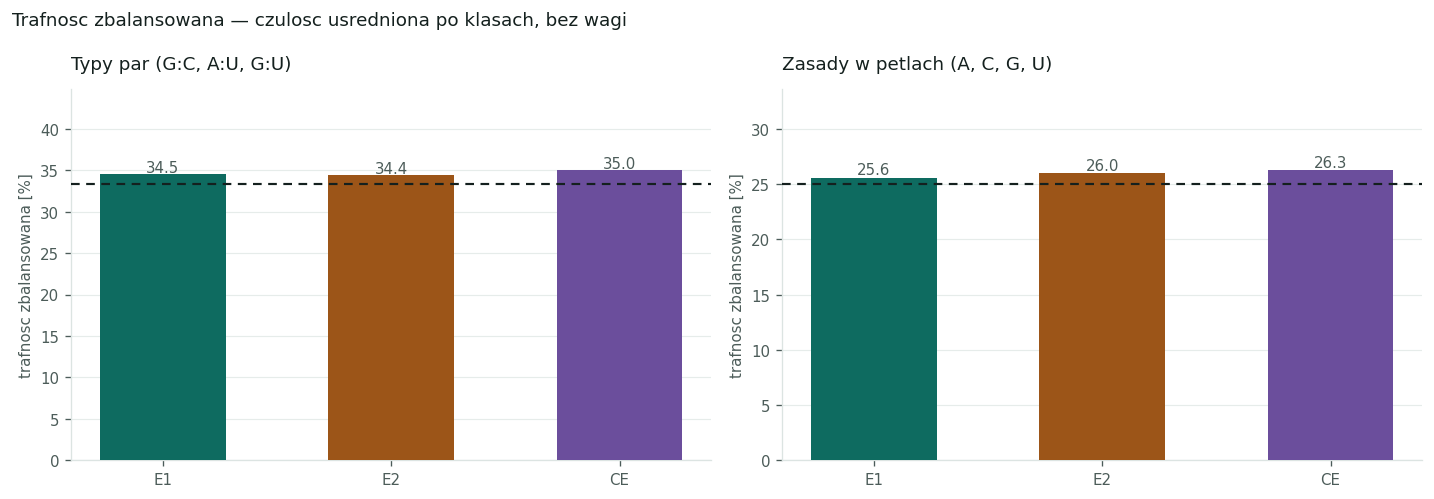

In [3]:
nat = d[(d.zbior == "test") & (d.dlugosc == "<= 200 nt")]

# BEZ BASELINE'U. Kazdy predyktor niezalezny od wejscia — a taki jest baseline — dostaje dokladnie
# 1/k, czyli lezy na linii odniesienia. Slupek nie wnosilby tu nic ponad nia. Na pozostalych
# wykresach baseline zostaje, bo tam linia oznacza co innego niz on.
MODELE_LAB = [l for l in LAB if l != "baseline"]

fig, axs = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, kol, poziom, tyt in ((axs[0], "zbal_par", LOSOWO_PAR, "Typy par (G:C, A:U, G:U)"),
                             (axs[1], "zbal_zasady", LOSOWO_ZAS, "Zasady w petlach (A, C, G, U)")):
    v = [float(nat[nat.etykieta == l][kol].iloc[0]) for l in MODELE_LAB]
    b = ax.bar(range(len(MODELE_LAB)), v, 0.55, color=[KOL[l] for l in MODELE_LAB], zorder=3)
    for r, vv in zip(b, v):
        ax.text(r.get_x() + r.get_width() / 2, vv + 0.3, f"{vv:.1f}", ha="center",
                fontsize=9, color=INK2)
    # Linia odniesienia: poziom losowy, czyli 1/3 dla typow par i 1/4 dla zasad.
    ax.axhline(poziom, color=INK, lw=1.3, ls=(0, (4, 3)), zorder=4)
    ax.set_xticks(range(len(MODELE_LAB)))
    ax.set_xticklabels(MODELE_LAB, fontsize=9)
    ax.set_ylim(0, max(v + [poziom]) * 1.28)
    styl(ax, tyt, "trafnosc zbalansowana [%]")
fig.suptitle("Trafnosc zbalansowana — czulosc usredniona po klasach, bez wagi",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

## 2. Czułość i specyficzność osobno dla każdej klasy

Dwie miary, które trzeba czytać razem, bo dopiero razem wykrywają **nadprodukcję jednej klasy**.

```
czulosc        z tych, ktore NAPRAWDE sa klasy c, ile model rozpoznal
specyficznosc  z tych, ktore NIE sa klasy c, ilu model NIE wrzucil do c
```

Predyktor „zawsze G:C" ma czułość G:C równą 100% i specyficzność G:C równą **zeru** — rozpoznaje
wszystkie prawdziwe G:C, ale za cenę wrzucenia do nich całej reszty. Sama czułość tego nie pokaże.

Baseline losuje jednostajnie, więc jego czułość wynosi 1/3 dla każdego typu pary i 1/4 dla każdej
zasady. Jest przez to płaski i stanowi naturalne odniesienie: **wszystko, co nie odstaje od niego,
nie skorzystało z wejścia**.

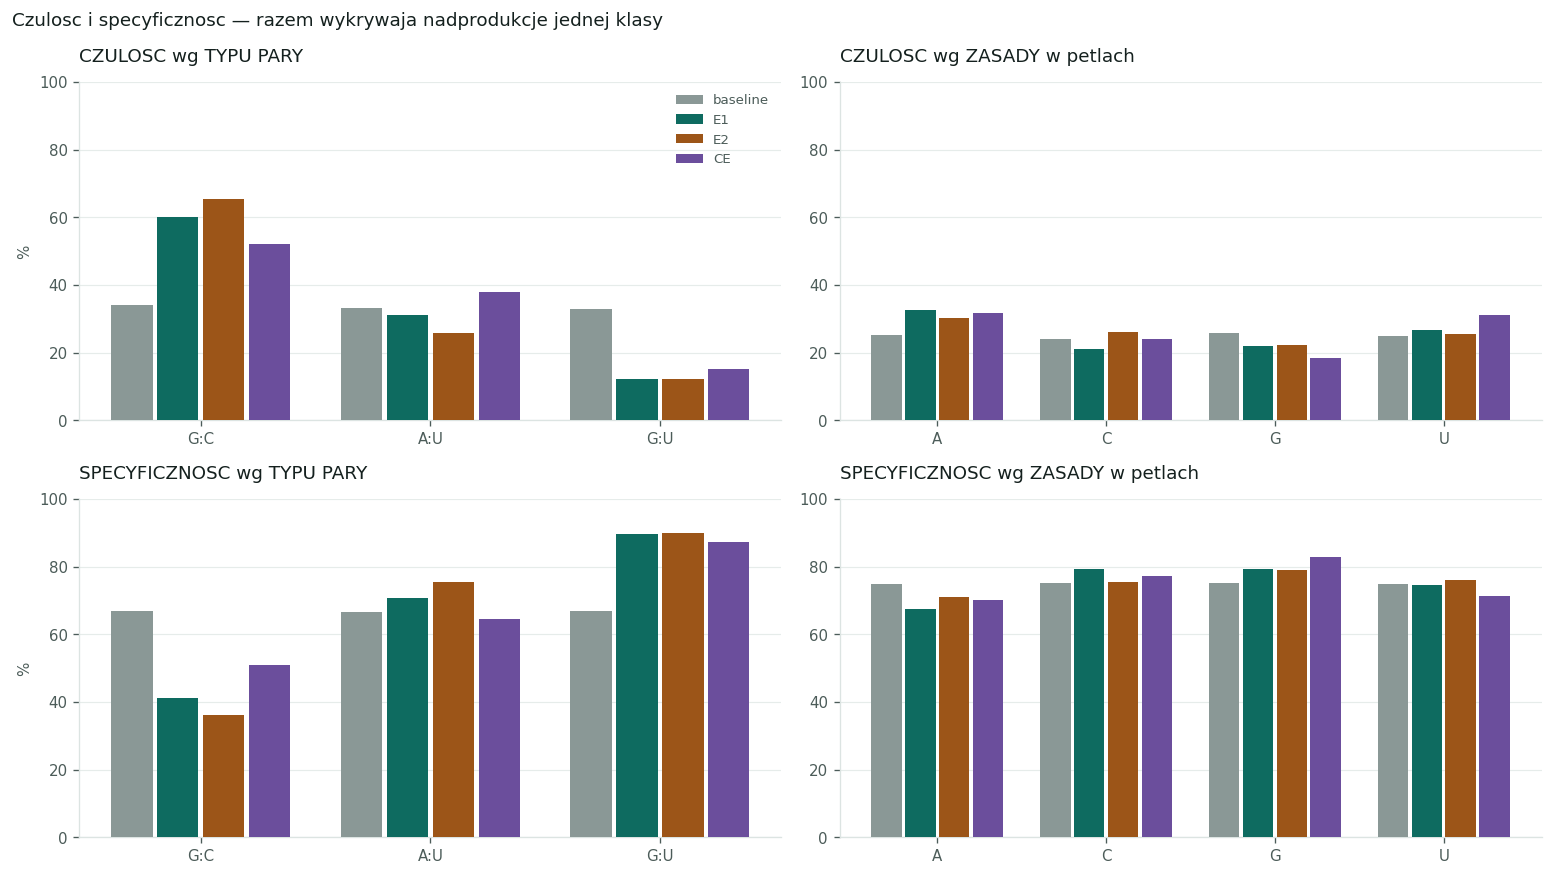

In [4]:
# Gorny rzad: czulosc. Dolny: specyficznosc. Bez linii odniesienia — poziom 1/k dotyczy SREDNIEJ
# po klasach, a nie pojedynczej klasy, wiec tutaj bylby mylacy. Odniesieniem jest slupek baseline'u.
GRUPY = ([("GC", "G:C"), ("AU", "A:U"), ("GU", "G:U")],
         [("petle_A", "A"), ("petle_C", "C"), ("petle_G", "G"), ("petle_U", "U")])

fig, axs = plt.subplots(2, 2, figsize=(13, 7.4))
for wiersz, (przedrostek, nazwa) in enumerate((("recall", "CZULOSC"), ("spec", "SPECYFICZNOSC"))):
    for kol, (grupa, co) in enumerate(zip(GRUPY, ("wg TYPU PARY", "wg ZASADY w petlach"))):
        ax = axs[wiersz][kol]
        x = np.arange(len(grupa))
        w = 0.8 / len(LAB)
        for k, l in enumerate(LAB):
            r = nat[nat.etykieta == l]
            v = [float(r[f"{przedrostek}_{c}"].iloc[0]) for c, _ in grupa]
            ax.bar(x + (k - (len(LAB) - 1) / 2) * w, v, w * 0.9, color=KOL[l],
                   label=l if (wiersz == 0 and kol == 0) else None, zorder=3)
        ax.set_xticks(x)
        ax.set_xticklabels([e for _, e in grupa], fontsize=10)
        ax.set_ylim(0, 100)
        styl(ax, f"{nazwa} {co}", "%" if kol == 0 else "")
axs[0][0].legend(frameon=False, fontsize=8, labelcolor=INK2)
fig.suptitle("Czulosc i specyficznosc — razem wykrywaja nadprodukcje jednej klasy",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

## 3. Identyczność sekwencyjna

Ile pozycji ma tę samą zasadę co referencja (lewy panel) i ile par ma trafiony typ (prawy).

Miara łatwiejsza do odczytania niż trafność zbalansowana, ale trzeba pamiętać o jej wadzie: **rośnie,
gdy model wskazuje klasę najczęstszą**, nawet jeśli robi to zawsze. Dlatego rozstrzygamy trafnością
zbalansowaną z sekcji 1, a tę traktujemy jako uzupełnienie. Baseline jest tu punktem odniesienia.

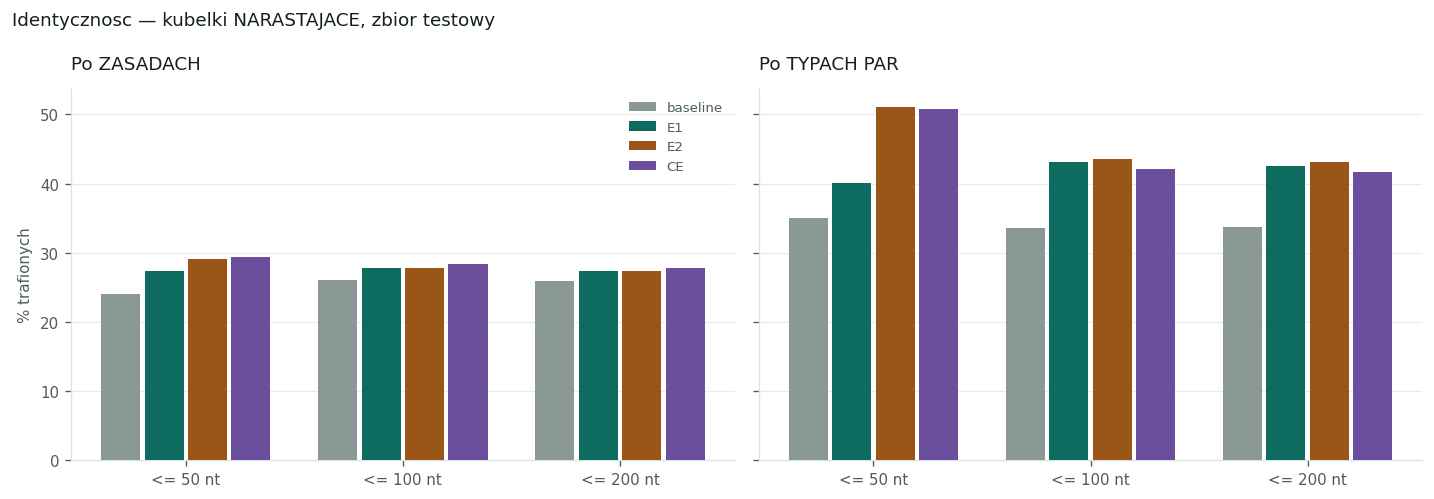

In [5]:
testy = d[d.zbior == "test"]
kubelki = list(dict.fromkeys(testy.dlugosc))

fig, axs = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
x = np.arange(len(kubelki))
w = 0.8 / len(LAB)
for ax, kol, tyt in ((axs[0], "identycznosc_nt", "Po ZASADACH"),
                     (axs[1], "identycznosc_par", "Po TYPACH PAR")):
    for k, l in enumerate(LAB):
        v = [float(testy[(testy.etykieta == l) & (testy.dlugosc == kk)][kol].iloc[0])
             for kk in kubelki]
        ax.bar(x + (k - (len(LAB) - 1) / 2) * w, v, w * 0.9, color=KOL[l],
               label=l if ax is axs[0] else None, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(kubelki, fontsize=9)
    styl(ax, tyt, "% trafionych" if ax is axs[0] else "")
axs[0].legend(frameon=False, fontsize=8, labelcolor=INK2)
fig.suptitle("Identycznosc — kubelki NARASTAJACE, zbior testowy",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

## 4. Energia

`dE/nt` mowi, o ile stabilniej nasza sekwencja trzyma zadana strukture niz sekwencja referencyjna; ujemne
znaczy stabilniej. Uwaga przy odczycie: **bardzo ujemne wartosci to sygnal degeneracji**, a nie sukces.
Sekwencje zlozone z samych par G:C maja srednio -0,59 kcal/mol/nt, a prawdziwe RNA tylko -0,28 —
natura celowo nie schodzi do minimum energii, bo czasteczka maksymalnie stabilna zwijalaby sie
rownie chetnie na wiele sposobow.

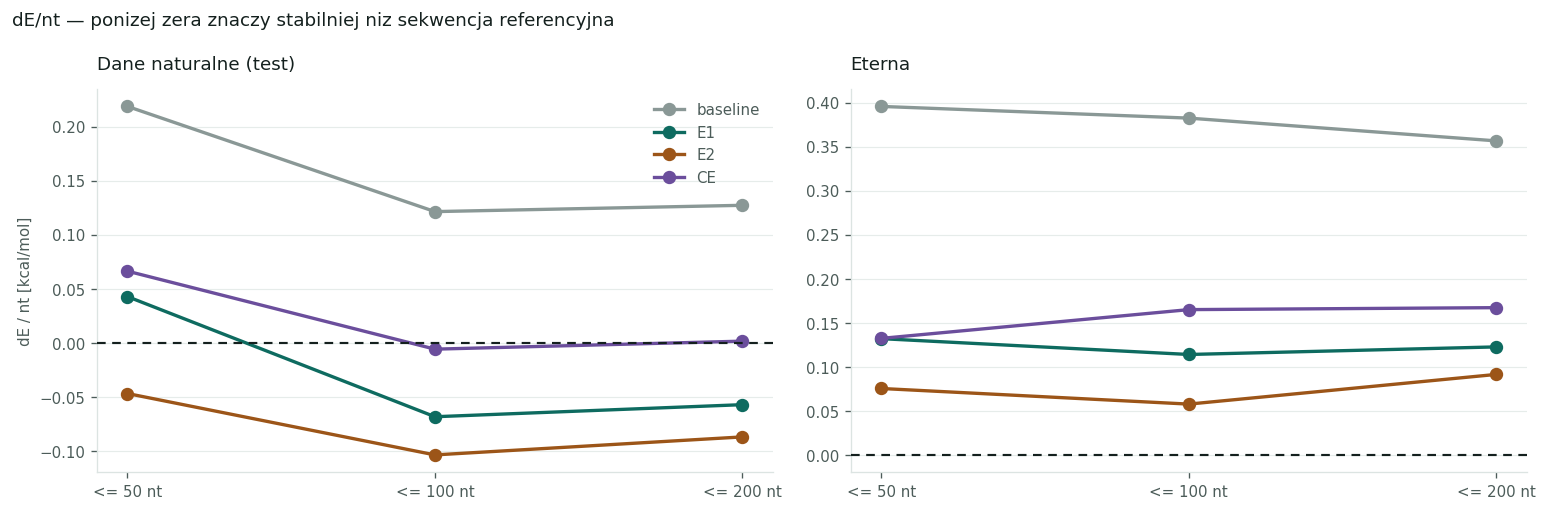

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.3))
for ax, zb, tyt in ((axs[0], "test", "Dane naturalne (test)"),
                    (axs[1], "eterna", "Eterna")):
    czesc = d[d.zbior == zb]
    kk = list(dict.fromkeys(czesc.dlugosc))
    for l in LAB:
        v = [float(czesc[(czesc.etykieta == l) & (czesc.dlugosc == k)].dE_nt.iloc[0])
             for k in kk]
        ax.plot(range(len(kk)), v, "-o", color=KOL[l], lw=2, ms=7, label=l if ax is axs[0] else None,
                zorder=3)
    ax.axhline(0, color=INK, lw=1.3, ls=(0, (4, 3)), zorder=4)
    ax.set_xticks(range(len(kk)))
    ax.set_xticklabels(kk, fontsize=9)
    styl(ax, tyt, "dE / nt [kcal/mol]" if ax is axs[0] else "")
axs[0].legend(frameon=False, fontsize=9, labelcolor=INK2)
fig.suptitle("dE/nt — ponizej zera znaczy stabilniej niz sekwencja referencyjna",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

## 5. Co model faktycznie wypisuje

Do tej pory patrzyliśmy na miary. Teraz generujemy sekwencje i oglądamy ich skład. **Dekodowanie musi
być takie samo jak w treningu danego modelu**, inaczej porównywalibyśmy co innego niż raportujemy.

Ta sekcja wymaga GPU i checkpointów.

In [7]:
import torch
import random

from src.evaluate import wczytaj_model, generuj
from src.dataset import losowa_kanoniczna

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baza = wczytaj()
idx = wczytaj_split("rodzinowy")["test"]
S = baza.secondary_structure.iloc[idx].tolist()
Q = baza.sequence.iloc[idx].tolist()

# (etykieta, checkpoint, dekodowanie) — dekodowanie MUSI zgadzac sie z trybem treningu.
MODELE = [("E1", "checkpoints/e1_sklad_tv.pt", "probkowanie"),
          ("E2", "checkpoints/e2_sklad_progi.pt", "probkowanie"),
          ("CE", "checkpoints/ce_sama_ce.pt", "probkowanie")]

# Baseline generujemy tak samo jak reszte, zeby byl na wykresach skladu obok modeli.
random.seed(0)
gen = {"baseline": [losowa_kanoniczna(t) for t in S]}
for lab, ck, dek in MODELE:
    if (Path.cwd().parent / ck).exists():
        m, _ = wczytaj_model(ck, dev)
        gen[lab] = generuj(m, S, dev, dekodowanie=dek, seed=0)
        del m
        torch.cuda.empty_cache()
        print(f"{lab:<9} {dek}")
    else:
        print(f"brak {ck}")
print(f"wygenerowano dla {len(S)} struktur testowych")

C:\Users\janle\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


E1        probkowanie


E2        probkowanie


CE        probkowanie
wygenerowano dla 728 struktur testowych


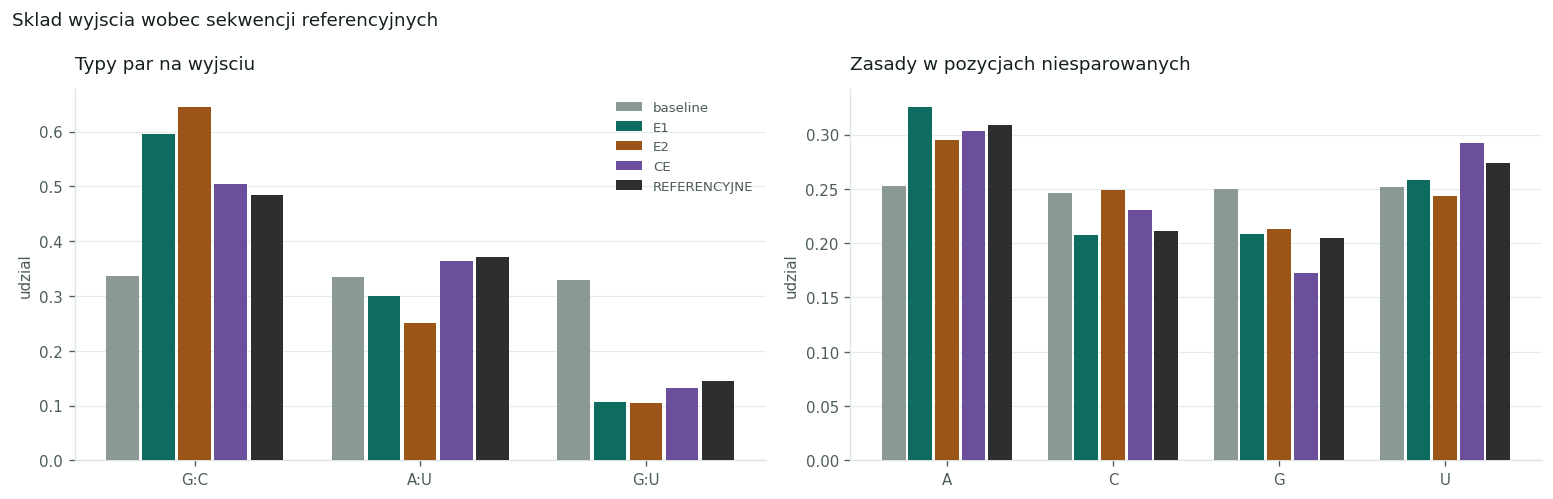

In [8]:
zrodla_m = list(gen.items()) + [("REFERENCYJNE", Q)]
kolory_m = {**KOL, "REFERENCYJNE": "#2E2E2E"}

fig, axs = plt.subplots(1, 2, figsize=(13, 4.2))
x = np.arange(3)
w = 0.8 / len(zrodla_m)
for k, (l, g) in enumerate(zrodla_m):
    t = typy_par(S, g)
    tot = sum(t.values()) or 1
    v = [t[kk] / tot for kk in ("G:C", "A:U", "G:U")]
    axs[0].bar(x + (k - (len(zrodla_m) - 1) / 2) * w, v, w * 0.9,
               color=kolory_m.get(l, C4), label=l, zorder=3)
axs[0].set_xticks(x)
axs[0].set_xticklabels(["G:C", "A:U", "G:U"], fontsize=10)
styl(axs[0], "Typy par na wyjsciu", "udzial")
axs[0].legend(frameon=False, fontsize=8, labelcolor=INK2)

x = np.arange(4)
petle = ["spinka", "wybrzuszenie", "multipetla", "regiony-zewnetrzne"]
for k, (l, g) in enumerate(zrodla_m):
    c = sklad_motywy(S, g)
    lacz = Counter()
    for m_ in petle:
        lacz.update(c[m_])
    tot = sum(lacz.values()) or 1
    axs[1].bar(x + (k - (len(zrodla_m) - 1) / 2) * w, [lacz[b] / tot for b in BASES], w * 0.9,
               color=kolory_m.get(l, C4), zorder=3)
axs[1].set_xticks(x)
axs[1].set_xticklabels(BASES, fontsize=10)
styl(axs[1], "Zasady w pozycjach niesparowanych", "udzial")
fig.suptitle("Sklad wyjscia wobec sekwencji referencyjnych",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

## 6. Degeneracja wg motywu

Najostrzejszy obraz problemu. Jeśli model wypełnia wszystkie typy pętli tą samą zasadą, znaczy to, że
nie rozróżnia motywów — a to była cała nadzieja związana z transformerem patrzącym holistycznie.

UDZIAL ADENINY w pozycjach niesparowanych

motyw                   pozycji      baseline            E1            E2            CE  REFERENCYJNE


spinka                     9376         0.251         0.333         0.285         0.286         0.286


wybrzuszenie              12636         0.254         0.323         0.300         0.323         0.313


multipetla                 1217         0.243         0.339         0.319         0.327         0.439


regiony-zewnetrzne         7322         0.253         0.319         0.294         0.290         0.311


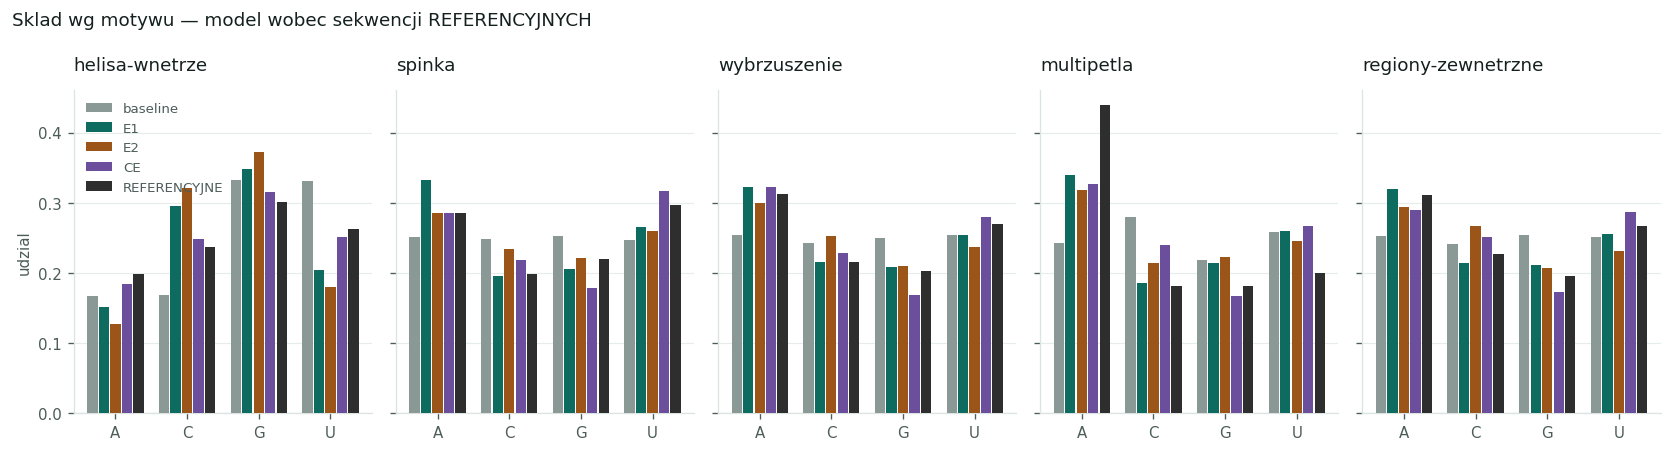

In [9]:
pokaz = ["helisa-wnetrze", "spinka", "wybrzuszenie", "multipetla", "regiony-zewnetrzne"]
fig, axs = plt.subplots(1, len(pokaz), figsize=(14, 3.8), sharey=True)
x = np.arange(4)
w = 0.8 / len(zrodla_m)
for ax, m_ in zip(axs, pokaz):
    for k, (l, g) in enumerate(zrodla_m):
        c = sklad_motywy(S, g)[m_]
        t = sum(c.values()) or 1
        ax.bar(x + (k - (len(zrodla_m) - 1) / 2) * w, [c[b] / t for b in BASES], w * 0.9,
               color=kolory_m.get(l, C4), label=l if m_ == pokaz[0] else None, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(BASES, fontsize=9)
    styl(ax, m_, "udzial" if m_ == pokaz[0] else "")
axs[0].legend(frameon=False, fontsize=8, labelcolor=INK2)
fig.suptitle("Sklad wg motywu — model wobec sekwencji REFERENCYJNYCH",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

print("UDZIAL ADENINY w pozycjach niesparowanych\n")
print(f"{'motyw':<22}{'pozycji':>9}" + "".join(f"{l:>14}" for l, _ in zrodla_m))
for mot in ["spinka", "wybrzuszenie", "multipetla", "regiony-zewnetrzne"]:
    n = sum(sklad_motywy(S, Q)[mot].values())
    kom = ""
    for l, g in zrodla_m:
        c = sklad_motywy(S, g)[mot]
        t = sum(c.values()) or 1
        kom += f"{c['A'] / t:>14.3f}"
    print(f"{mot:<22}{n:>9}" + kom)

---

# Warianty z wazona cross-entropia — przygotowanie

`E1W`, `E2W` i `CEW` to te same trzy konfiguracje co wyzej, ale z **CE wazona odwrotnie do czestosci
klas**. Wagi `1/czestosc` liczone na TRENINGU, znormalizowane do sredniej 1, wiec skala straty sie
nie zmienia.

**Po co.** Zwykla CE optymalizuje trafienia wazone liczebnoscia, wiec klasa G:C (60% par
treningowych) wnosi do gradientu osiem razy wiecej niz G:U (5%). Modelowi oplaca sie wtedy zbudowac
wokol klasy najczestszej. Wagi to usuwaja — sa **odpowiednikiem trafnosci zbalansowanej po stronie
uczenia**, tak jak `zbal_par` jest nim po stronie pomiaru.

Nie pokazujemy ich w osobnym zestawie wykresow. Wazenie ma sens wylacznie **w odniesieniu do swojego
odpowiednika bez wazenia**, wiec caly material jest w zestawie III, gdzie kazda para stoi obok
siebie i rozni ja dokladnie jedna rzecz. Ponizsze dwie komorki tylko przygotowuja dane.


In [10]:
# Osobny slownik i osobna paleta, zeby ZESTAW I pozostal nietkniety.
PLIKI_W = {
    "baseline": "baseline_test.csv",
    "E1W":      "e1w_test.csv",
    "E2W":      "e2w_test.csv",
    "CEW":      "cew_test.csv",
}

kawalki_w = []
for lab, p in PLIKI_W.items():
    f = ANALIZA / p
    if f.exists():
        x = pd.read_csv(f)
        x["etykieta"] = lab
        kawalki_w.append(x)
    else:
        print(f"brak {p} — uruchom odpowiedni eksperyment")

dw = pd.concat(kawalki_w, ignore_index=True) if kawalki_w else pd.DataFrame()
LAB_W = [l for l in PLIKI_W if l in set(dw.etykieta)] if len(dw) else []
# Te same kolory co odpowiedniki z zestawu I: baseline szary, kara TV zielona, progi brazowe,
# ablacja fioletowa. Dzieki temu oba zestawy czyta sie tym samym kluczem.
KOL_W = {"baseline": C4, "E1W": C1, "E2W": C2, "CEW": C3}

display(dw[(dw.zbior == "test") & (dw.dlugosc == "<= 200 nt")][KOLUMNY]
        .set_index("etykieta").round(3))
print(f"poziom losowy:  zbal_par {LOSOWO_PAR:.1f}%   zbal_zas {LOSOWO_ZAS:.1f}%")

,n,identycznosc_nt,identycznosc_par,zbal_par,zbal_zasady,dE_nt,kara_wlasna
etykieta,,,,,,,
baseline,728,25.948,33.699,33.460,25.031,0.127,NaN
E1W,728,26.715,41.179,34.334,25.430,-0.029,0.226
E2W,728,26.812,42.105,34.664,25.886,-0.044,0.108
CEW,728,26.301,35.780,34.458,25.647,0.141,NaN


poziom losowy:  zbal_par 33.3%   zbal_zas 25.0%


In [11]:
# Sekwencje dla wariantow wazonych. `gen`, `S` i `Q` z pierwszej czesci zostaja nietkniete.
MODELE_W_CK = [("E1W", "checkpoints/e1w_wazona_ce.pt"),
               ("E2W", "checkpoints/e2w_wazona_ce.pt"),
               ("CEW", "checkpoints/cew_wazona_ce.pt")]

genw = {"baseline": gen["baseline"]}   # ten sam baseline co wyzej
for lab, ck in MODELE_W_CK:
    if (Path.cwd().parent / ck).exists():
        mw, _ = wczytaj_model(ck, dev)
        genw[lab] = generuj(mw, S, dev, dekodowanie="probkowanie", seed=0)
        del mw
        torch.cuda.empty_cache()
        print(f"{lab:<9} probkowanie")
    else:
        print(f"brak {ck}")

C:\Users\janle\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


E1W       probkowanie


E2W       probkowanie


CEW       probkowanie


---

# ZESTAW II — co robi samo wazenie klas

Tu kazda konfiguracja stoi obok swojego odpowiednika, w **parach**, w ktorych jedyna
roznica to wazenie CE:

```
E1  <->  E1W     kara TV za sklad,        bez wagi / z waga
E2  <->  E2W     kara progowa promotora,  bez wagi / z waga
CE  <->  CEW     bez kar,                 bez wagi / z waga
```

Wszystko inne — dane, podzial, architektura, wagi kar, dekodowanie, kryterium wyboru epoki, liczba
epok — jest w obrebie pary identyczne. **Kazda roznica wewnatrz slupka podwojnego pochodzi wiec
wylacznie od wazenia**, i to jest jedyny uklad w calym notatniku, ktory pozwala to powiedziec.

Slupek jasny z kreskowaniem = wersja wazona. Kolor oznacza pare, tak jak w pierwszym
zestawach.

**Uwaga o wielkosci roznic.** Zmierzony rozrzut `zbal_par` miedzy ziarnami inicjalizacji wynosi
**±0,26 pp** (12 przebiegow, `experiments/analysis/szum_wagi_klas.csv`). Roznice mniejsze niz mniej
wiecej 0,7 pp nalezy czytac jako brak roznicy.

In [12]:
# Laczymy wersje niewazone i wazone w jedna ramke.
PARY = [("E1", "E1W", C1), ("E2", "E2W", C2), ("CE", "CEW", C3)]

def _wiersz(tab, lab):
    r = tab[(tab.etykieta == lab) & (tab.zbior == "test") & (tab.dlugosc == "<= 200 nt")]
    return r.iloc[0] if len(r) else None

WIERSZ = {}
for a, b, _ in PARY:
    WIERSZ[a] = _wiersz(d, a)
    WIERSZ[b] = _wiersz(dw, b)
brak = [k for k, v in WIERSZ.items() if v is None]
if brak:
    print("BRAK wynikow dla:", brak, "— uruchom odpowiednie eksperymenty")

def youden(r, klasy):
    """Czulosc + specyficznosc - 1, usredniona po klasach. Poziom odniesienia = 0."""
    return sum((r[f"recall_{k}"] + r[f"spec_{k}"] - 100) for k in klasy) / len(klasy)

# Sklad wyjscia — z sekwencji wygenerowanych wyzej.
WSZ_GEN = {**{k: v for k, v in gen.items() if k != "baseline"},
           **{k: v for k, v in genw.items() if k != "baseline"}}

def _sklad(seqs):
    """Udzialy typow par (G:C, A:U, G:U) oraz zasad w pozycjach niesparowanych (A, C, G, U)."""
    t = typy_par(S, seqs)
    tp = sum(t.values()) or 1
    par = [t[k] / tp for k in ("G:C", "A:U", "G:U")]
    c = sklad_motywy(S, seqs)
    lacz = Counter()
    for m_ in ["spinka", "wybrzuszenie", "multipetla", "regiony-zewnetrzne"]:
        lacz.update(c[m_])
    tz = sum(lacz.values()) or 1
    return par, [lacz[b] / tz for b in BASES]

SKLAD = {k: _sklad(v) for k, v in WSZ_GEN.items()}
REF_PAR, REF_ZAS = _sklad(Q)

print(f"{'model':<6}{'zbal_par':>10}{'zbal_zas':>10}{'Youden par':>12}{'id_nt':>8}"
      f"{'id_par':>8}{'dE/nt':>9}{'G:C wyj':>9}{'A w petl':>10}")
for a, b, _ in PARY:
    for l in (a, b):
        r = WIERSZ[l]
        if r is None:
            continue
        print(f"{l:<6}{r.zbal_par:>9.2f}%{r.zbal_zasady:>9.2f}%"
              f"{youden(r, ('GC','AU','GU'))/100:>+12.4f}{r.identycznosc_nt:>7.2f}%"
              f"{r.identycznosc_par:>7.2f}%{r.dE_nt:>9.4f}"
              f"{SKLAD[l][0][0]:>9.3f}{SKLAD[l][1][0]:>10.3f}")
    print()
print(f"REFERENCJA{'':<44}{REF_PAR[0]:>9.3f}{REF_ZAS[0]:>10.3f}")


model   zbal_par  zbal_zas  Youden par   id_nt  id_par    dE/nt  G:C wyj  A w petl
E1        34.49%    25.60%     +0.0170  27.37%  42.61%  -0.0571    0.595     0.326
E1W       34.33%    25.43%     +0.0135  26.71%  41.18%  -0.0293    0.552     0.321

E2        34.38%    25.98%     +0.0152  27.40%  43.16%  -0.0869    0.645     0.295
E2W       34.66%    25.89%     +0.0179  26.81%  42.11%  -0.0439    0.577     0.233

CE        35.00%    26.27%     +0.0256  27.76%  41.69%   0.0017    0.505     0.304
CEW       34.46%    25.65%     +0.0152  26.30%  35.78%   0.1406    0.297     0.234

REFERENCJA                                                0.484     0.309


## II.1. Wszystkie miary rozstrzygające, parami

Sześć paneli, w każdym trzy pary. Czarna linia przerywana to poziom odniesienia dla danej miary.

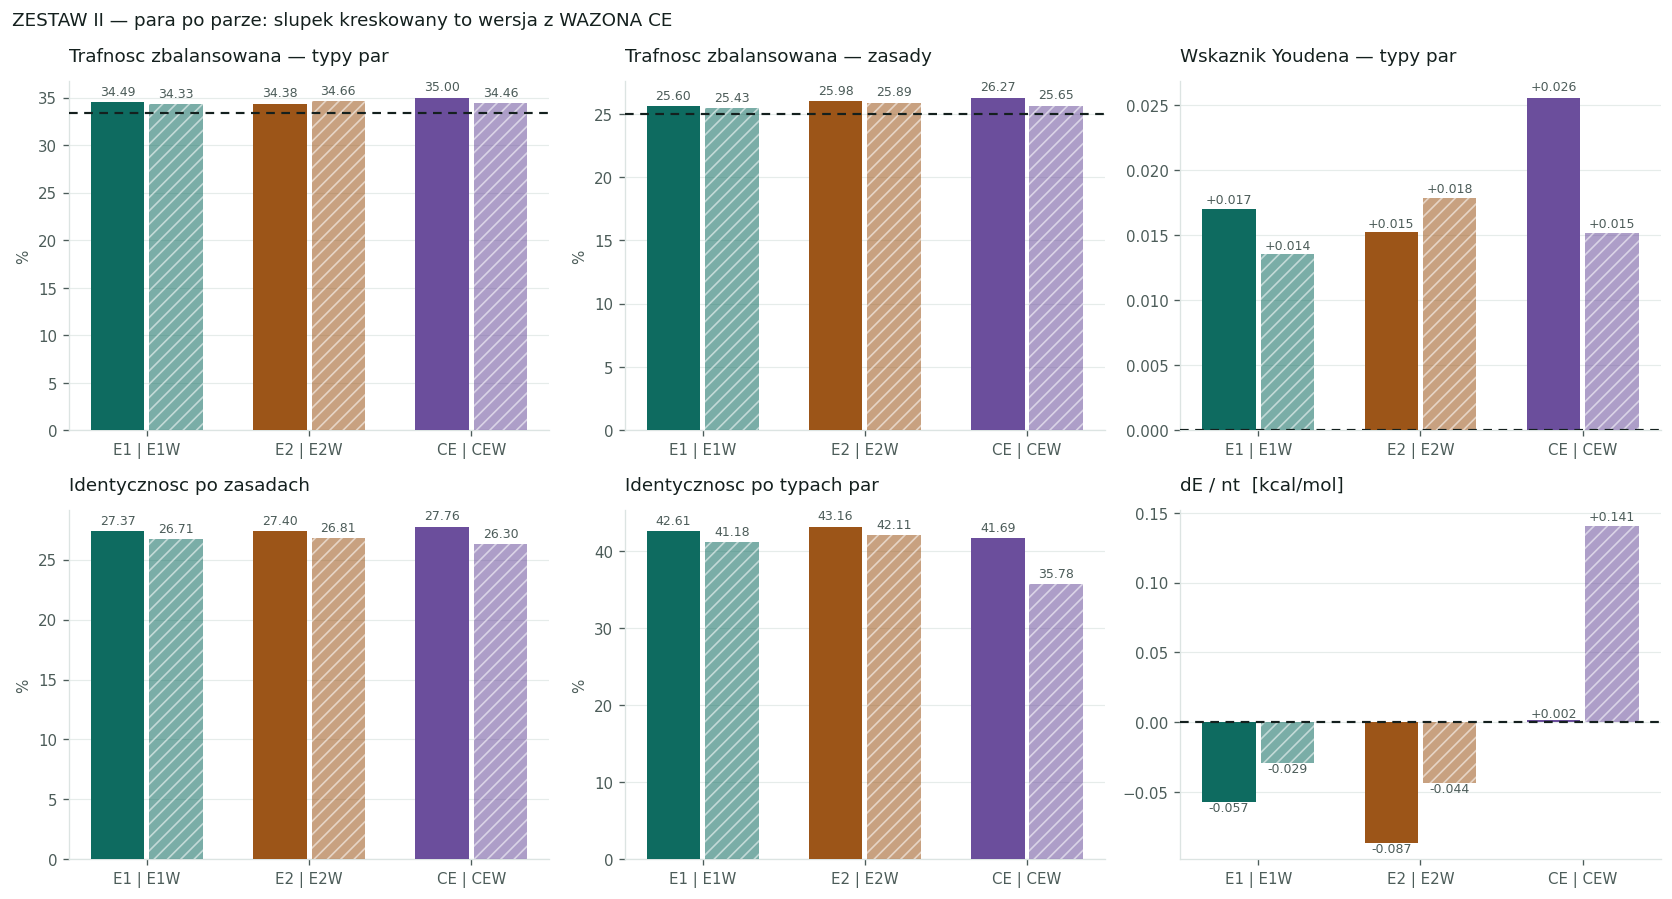

In [13]:
MIARY = [
    ("zbal_par",       "Trafnosc zbalansowana — typy par",      "%",   LOSOWO_PAR),
    ("zbal_zasady",    "Trafnosc zbalansowana — zasady",        "%",   LOSOWO_ZAS),
    ("youden_par",     "Wskaznik Youdena — typy par",           "",    0.0),
    ("identycznosc_nt", "Identycznosc po zasadach",             "%",   None),
    ("identycznosc_par", "Identycznosc po typach par",          "%",   None),
    ("dE_nt",          "dE / nt  [kcal/mol]",                   "",    0.0),
]

fig, axs = plt.subplots(2, 3, figsize=(14, 7.6))
for ax, (kol, tyt, jed, poziom) in zip(axs.ravel(), MIARY):
    x = np.arange(len(PARY))
    for k, (a, b, kolor) in enumerate(PARY):
        for j, l in enumerate((a, b)):
            r = WIERSZ[l]
            if r is None:
                continue
            v = youden(r, ("GC", "AU", "GU")) / 100 if kol == "youden_par" else float(r[kol])
            ax.bar(x[k] + (j - 0.5) * 0.36, v, 0.33, color=kolor,
                   alpha=1.0 if j == 0 else 0.55,
                   hatch="" if j == 0 else "///", edgecolor="white", linewidth=0, zorder=3)
            ax.text(x[k] + (j - 0.5) * 0.36, v + (0.012 * abs(v) if v else 0.001),
                    f"{v:.2f}" if jed else f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top",
                    fontsize=7.5, color=INK2)
    if poziom is not None:
        ax.axhline(poziom, color=INK, lw=1.3, ls=(0, (4, 3)), zorder=4)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{a} | {b}" for a, b, _ in PARY], fontsize=9)
    styl(ax, tyt, jed)
fig.suptitle("ZESTAW II — para po parze: slupek kreskowany to wersja z WAZONA CE",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

## II.2. Mechanizm — czułość i specyficzność klasa po klasie

Tu widać, *skąd* bierze się zmiana: ważenie odbiera czułość klasie najczęstszej i oddaje ją rzadkim.

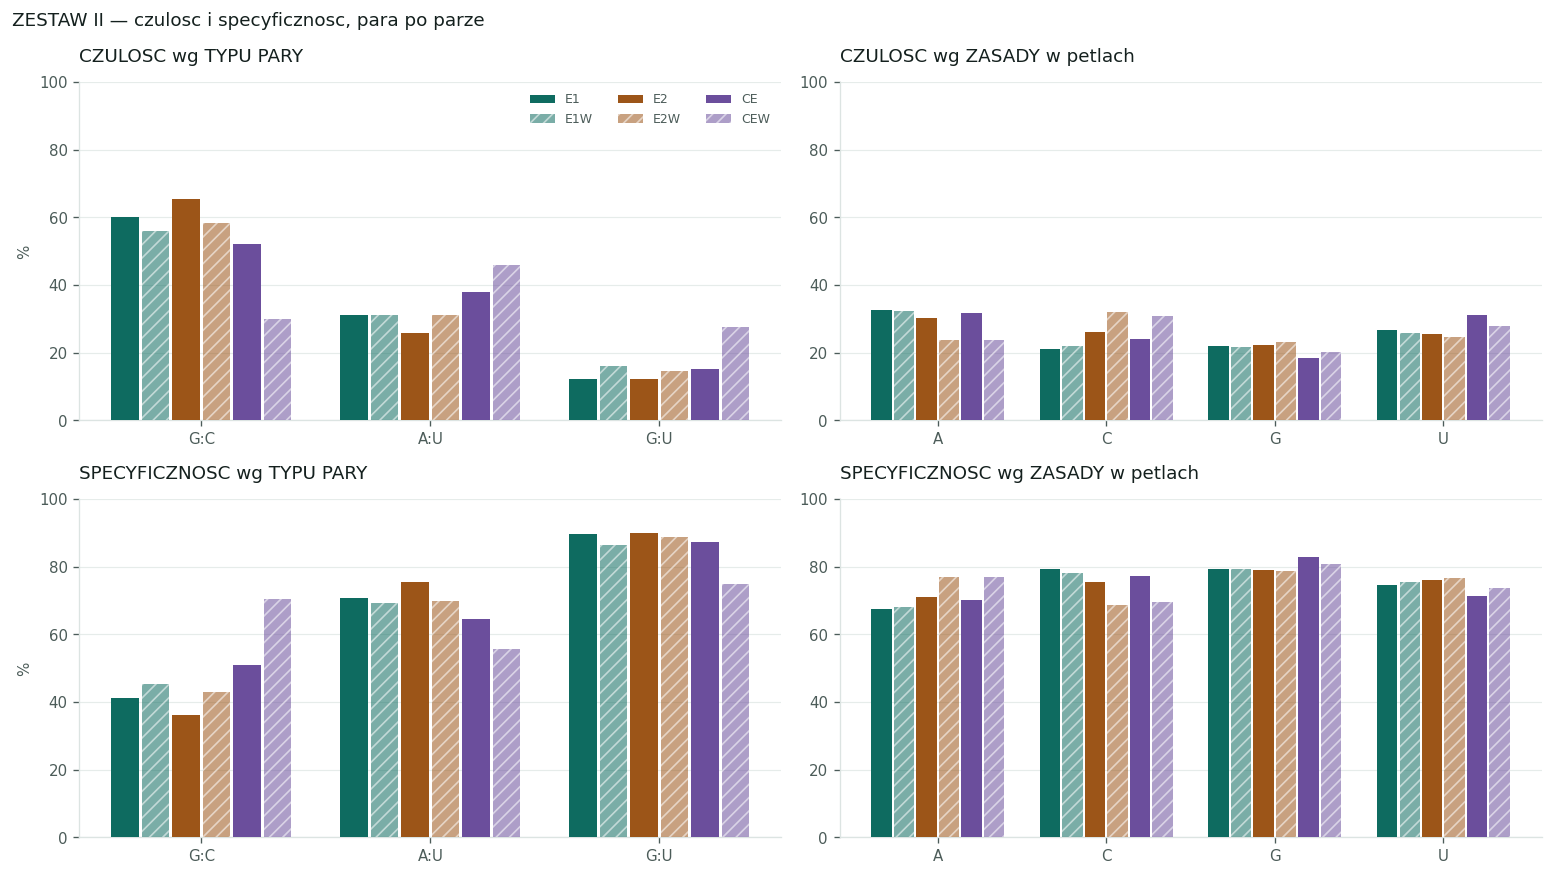

In [14]:
KLASY_P = [("GC", "G:C"), ("AU", "A:U"), ("GU", "G:U")]
KLASY_Z = [("petle_A", "A"), ("petle_C", "C"), ("petle_G", "G"), ("petle_U", "U")]

fig, axs = plt.subplots(2, 2, figsize=(13, 7.4))
for w, (przed, nazwa) in enumerate((("recall", "CZULOSC"), ("spec", "SPECYFICZNOSC"))):
    for kk, (grupa, cco) in enumerate(zip((KLASY_P, KLASY_Z),
                                          ("wg TYPU PARY", "wg ZASADY w petlach"))):
        ax = axs[w][kk]
        x = np.arange(len(grupa))
        szer = 0.8 / (2 * len(PARY))
        for k, (a, b, kolor) in enumerate(PARY):
            for j, l in enumerate((a, b)):
                r = WIERSZ[l]
                if r is None:
                    continue
                v = [float(r[f"{przed}_{c}"]) for c, _ in grupa]
                poz = x + (2 * k + j - (2 * len(PARY) - 1) / 2) * szer
                ax.bar(poz, v, szer * 0.9, color=kolor, alpha=1.0 if j == 0 else 0.55,
                       hatch="" if j == 0 else "///", edgecolor="white", linewidth=0,
                       label=l if (w == 0 and kk == 0) else None, zorder=3)
        ax.set_xticks(x)
        ax.set_xticklabels([e for _, e in grupa], fontsize=10)
        ax.set_ylim(0, 100)
        styl(ax, f"{nazwa} {cco}", "%" if kk == 0 else "")
axs[0][0].legend(frameon=False, fontsize=7.5, labelcolor=INK2, ncol=3)
fig.suptitle("ZESTAW II — czulosc i specyficznosc, para po parze",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

## II.3. Skład wyjścia, para po parze

Czarna linia przerywana w każdej kolumnie to wartość w sekwencjach referencyjnych. Tu widać, że
ważenie przesuwa skład **w drugą stronę** niż kara za skład.

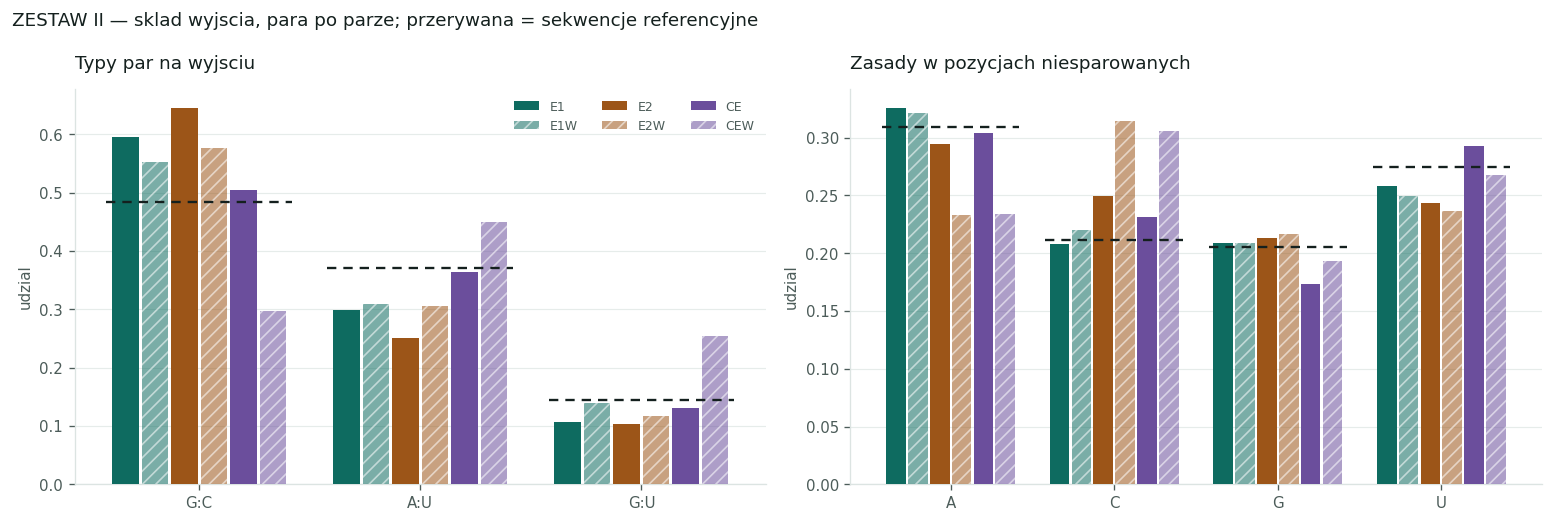

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, etyk, ref, idx in ((axs[0], ["G:C", "A:U", "G:U"], REF_PAR, 0),
                           (axs[1], BASES, REF_ZAS, 1)):
    x = np.arange(len(etyk))
    szer = 0.8 / (2 * len(PARY))
    for k, (a, b, kolor) in enumerate(PARY):
        for j, l in enumerate((a, b)):
            if l not in SKLAD:
                continue
            poz = x + (2 * k + j - (2 * len(PARY) - 1) / 2) * szer
            ax.bar(poz, SKLAD[l][idx], szer * 0.9, color=kolor, alpha=1.0 if j == 0 else 0.55,
                   hatch="" if j == 0 else "///", edgecolor="white", linewidth=0,
                   label=l if idx == 0 else None, zorder=3)
    for i, v in enumerate(ref):
        ax.plot([i - 0.42, i + 0.42], [v, v], color=INK, lw=1.4, ls=(0, (4, 3)), zorder=5)
    ax.set_xticks(x)
    ax.set_xticklabels(etyk, fontsize=10)
    styl(ax, "Typy par na wyjsciu" if idx == 0 else "Zasady w pozycjach niesparowanych", "udzial")
axs[0].legend(frameon=False, fontsize=7.5, labelcolor=INK2, ncol=3)
fig.suptitle("ZESTAW II — sklad wyjscia, para po parze; przerywana = sekwencje referencyjne",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

---

# ZESTAW III — Youden na treningu kontra rodziny nowe

Wskaznik Youdena wychodzi na tescie rzedu **+0,02**. To liczba doslowna: predyktor, ktory trafia
z prawdopodobienstwem `p`, a poza tym zgaduje, ma `J = p` dokladnie, wiec `J = 0,02` znaczy
**"model zna odpowiedz na 2% pozycji"**.

Pytanie, na ktore odpowiada ta sekcja: czy to sufit ZADANIA, czy nasz problem z danymi. Liczymy te
sama miare na TRENINGU — czyli na rodzinach, ktore model widzial setki razy.

```
jesli na treningu tez ~0,02   -> struktura nie wyznacza sekwencji, zadanie jest niewykonalne
jesli na treningu duzo wiecej -> zadanie jest wykonalne, a my nie umiemy tego PRZENIESC
```

Podzial jest rodzinowy, wiec walidacja i test skladaja sie z rodzin **nieobecnych w treningu**.
Zestawienie train/val/test jest tu wiec zestawieniem "rodziny widziane kontra nowe".

In [16]:
# Generujemy dla WSZYSTKICH trzech podzbiorow. Trening jest najwiekszy, wiec to chwile trwa.
from src.split import wczytaj_split as _ws
from src.dataset import parse_pairs as _pp
from src.evaluate import TYP_PARY as _TP

_spl = _ws("rodzinowy")
ZBIORY = {}
for _zb in ("train", "val", "test"):
    ZBIORY[_zb] = (baza.secondary_structure.iloc[_spl[_zb]].tolist(),
                   baza.sequence.iloc[_spl[_zb]].tolist())

MODELE_IV = [("E1", "checkpoints/e1_sklad_tv.pt", C1),
             ("E2", "checkpoints/e2_sklad_progi.pt", C2),
             ("CE", "checkpoints/ce_sama_ce.pt", C3),
             ("E1W", "checkpoints/e1w_wazona_ce.pt", C1),
             ("E2W", "checkpoints/e2w_wazona_ce.pt", C2),
             ("CEW", "checkpoints/cew_wazona_ce.pt", C3)]
WAZONY = {"E1W", "E2W", "CEW"}


def miary_par(structs, seqs, gen):
    """Zwraca (trafnosc zbalansowana w %, Youden). Youden = czulosc + specyficznosc - 1."""
    n, tp, wyd = Counter(), Counter(), Counter()
    for st, q, g in zip(structs, seqs, gen):
        for i, j in _pp(st):
            w = _TP.get(q[i] + q[j])
            if w is None:
                continue
            n[w] += 1
            p = _TP.get(g[i] + g[j])
            if p is not None:
                wyd[p] += 1
            if p == w:
                tp[w] += 1
    N = sum(n.values())
    cz, J = [], []
    for k in ("GC", "AU", "GU"):
        if not n[k]:
            continue
        czul = tp[k] / n[k]
        neg = N - n[k]
        cz.append(czul)
        J.append(czul + (neg - (wyd[k] - tp[k])) / neg - 1)
    return 100 * np.mean(cz), float(np.mean(J))


WYN_IV = {}
for lab, ck, _ in MODELE_IV:
    if not (Path.cwd().parent / ck).exists():
        print(f"brak {ck}")
        continue
    mm, _ = wczytaj_model(ck, dev)
    WYN_IV[lab] = {}
    for zb, (ss, qq) in ZBIORY.items():
        gg = generuj(mm, ss, dev, dekodowanie="probkowanie", seed=0)
        WYN_IV[lab][zb] = miary_par(ss, qq, gg)
    del mm
    torch.cuda.empty_cache()
    print(f"{lab:<5} " + "  ".join(
        f"{z} J={WYN_IV[lab][z][1]:+.4f}" for z in ("train", "val", "test")))

C:\Users\janle\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


E1    train J=+0.3222  val J=+0.0202  test J=+0.0170


E2    train J=+0.3279  val J=+0.0158  test J=+0.0152


CE    train J=+0.3964  val J=+0.0284  test J=+0.0256


E1W   train J=+0.3589  val J=+0.0244  test J=+0.0135


E2W   train J=+0.4060  val J=+0.0327  test J=+0.0179


CEW   train J=+0.3684  val J=+0.0363  test J=+0.0152


## III.1. Zapaść między rodzinami widzianymi a nowymi


model     J train     J val    J test    spadek train->test
E1        +0.3222   +0.0202   +0.0170                 19x
E2        +0.3279   +0.0158   +0.0152                 22x
CE        +0.3964   +0.0284   +0.0256                 16x
E1W       +0.3589   +0.0244   +0.0135                 27x
E2W       +0.4060   +0.0327   +0.0179                 23x
CEW       +0.3684   +0.0363   +0.0152                 24x


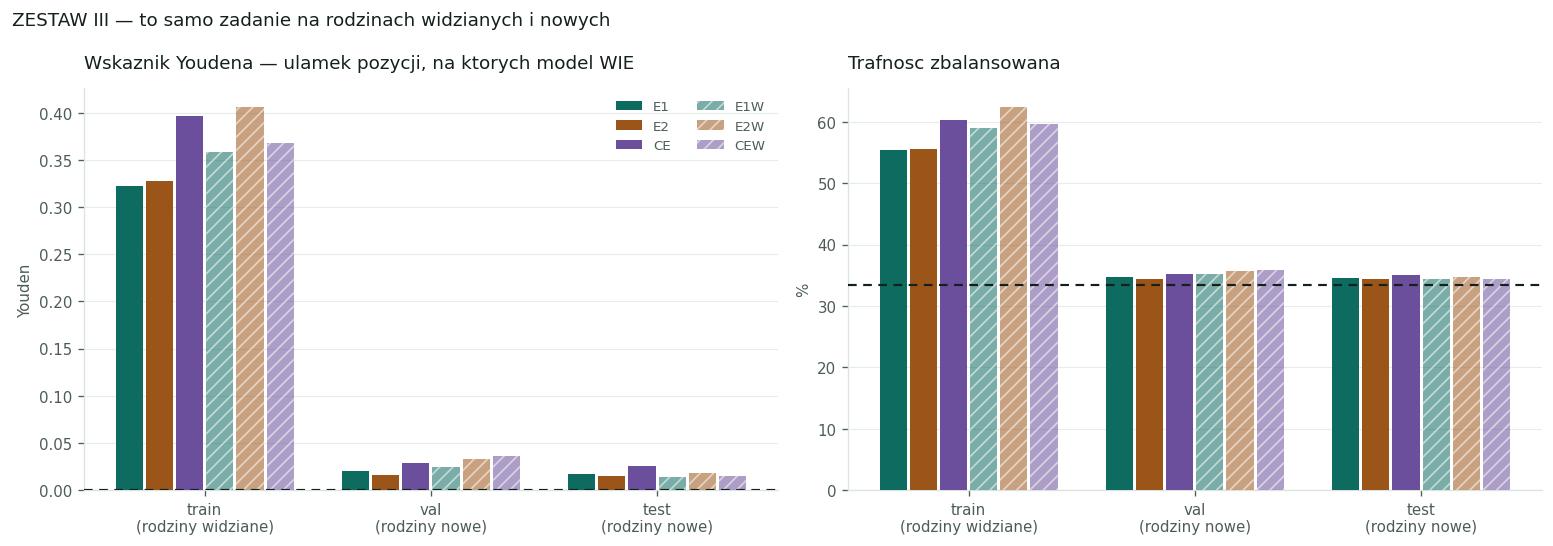

In [17]:
ETY = ["train\n(rodziny widziane)", "val\n(rodziny nowe)", "test\n(rodziny nowe)"]
KLU = ["train", "val", "test"]
LAB_IV = [l for l, _, _ in MODELE_IV if l in WYN_IV]

fig, axs = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, idx, tyt, ylab, poziom in (
        (axs[0], 1, "Wskaznik Youdena — ulamek pozycji, na ktorych model WIE", "Youden", 0.0),
        (axs[1], 0, "Trafnosc zbalansowana", "%", LOSOWO_PAR)):
    x = np.arange(len(KLU))
    w = 0.8 / len(LAB_IV)
    for k, l in enumerate(LAB_IV):
        kolor = dict((a, c) for a, _, c in MODELE_IV)[l]
        v = [WYN_IV[l][z][idx] for z in KLU]
        ax.bar(x + (k - (len(LAB_IV) - 1) / 2) * w, v, w * 0.9, color=kolor,
               alpha=1.0 if l not in WAZONY else 0.55,
               hatch="" if l not in WAZONY else "///", edgecolor="white", linewidth=0,
               label=l if ax is axs[0] else None, zorder=3)
    ax.axhline(poziom, color=INK, lw=1.3, ls=(0, (4, 3)), zorder=4)
    ax.set_xticks(x)
    ax.set_xticklabels(ETY, fontsize=9)
    styl(ax, tyt, ylab)
axs[0].legend(frameon=False, fontsize=8, labelcolor=INK2, ncol=2)
fig.suptitle("ZESTAW III — to samo zadanie na rodzinach widzianych i nowych",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

print(f"\n{'model':<7}{'J train':>10}{'J val':>10}{'J test':>10}{'spadek train->test':>22}")
for l in LAB_IV:
    jt, jv, js = (WYN_IV[l][z][1] for z in KLU)
    print(f"{l:<7}{jt:>+10.4f}{jv:>+10.4f}{js:>+10.4f}{jt / js if js else float('nan'):>19.0f}x")